In [2]:
import numpy as np
import matplotlib.pyplot as plt

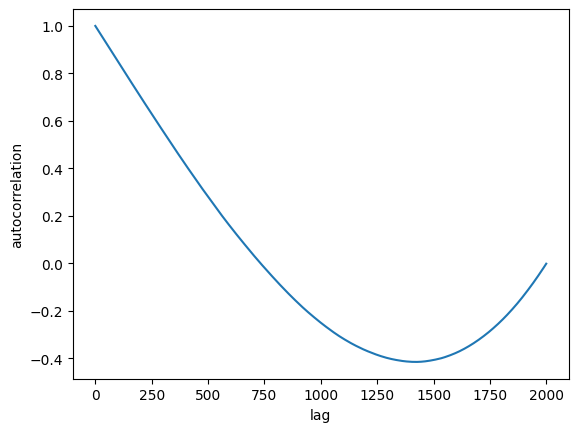

In [3]:
# simulate a Poisson process and compute the autocorrelation function
def simulate_poisson_process(lam, T):
    # generate the inter-arrival times
    inter_arrival_times = np.random.exponential(1/lam, int(lam*T*2))
    # compute the arrival times
    arrival_times = np.cumsum(inter_arrival_times)
    # compute the number of arrivals at each time
    n = np.zeros(int(lam*T*2))
    for i in range(int(lam*T*2)):
        n[i] = np.sum(arrival_times < i)
    return n

def autocorrelation(n):
    # compute the mean
    mean = np.mean(n)
    # compute the autocorrelation
    ac = np.zeros(len(n))
    for k in range(len(n)):
        ac[k] = np.sum((n[:len(n)-k] - mean)*(n[k:] - mean))/np.sum((n - mean)**2)
    return ac

# parameters
lam = 1
T = 1000
# simulate a Poisson process
n = simulate_poisson_process(lam, T)
# compute the autocorrelation
ac = autocorrelation(n)

# plot the autocorrelation
plt.figure()
plt.plot(ac)
plt.xlabel('lag')
plt.ylabel('autocorrelation')
plt.show()